In [1]:
import numpy as np
x = np.array([0, 1, 2, 3])
y = np.array([-1, 0.2, 0.9, 2.1])
#Перепишем линейное уравнение у = mx + с как у = Аp, где A = [[ x 1 ]] u p = [[m], [c]]
#Построим А по х :
A = np.vstack([x, np.ones(len(x))]).T
A

array([[0., 1.],
       [1., 1.],
       [2., 1.],
       [3., 1.]])

In [2]:
#Используем метод lstsq для решения его относительно вектора р.
m, c = np.linalg.lstsq(A, y, rcond = None)[0]
print(m, c)

0.9999999999999999 -0.9499999999999994


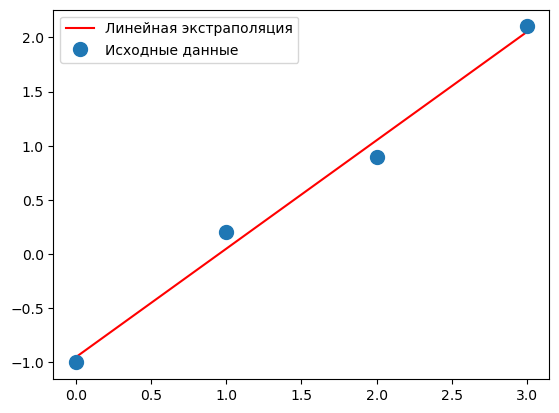

In [3]:
#Построим график полученной прямой и укажем на нем точки.
import matplotlib.pyplot as plt
plt.plot(x, m*x + c, 'r', label='Линейная экстраполяция')
plt.plot(x, y, 'o', label='Исходные данные', markersize=10)
plt.legend()
plt.show()

In [4]:
from numpy import *
from numpy.random import *
#генерируем случайные х и у
delta = 1.0
x = linspace(-5,5,11)
y = x**2+delta*(rand(11)-0.5)
x += delta*(rand(11)-0.5)
#записывае данные в файл
x.tofile('x_data.txt', '\n')
y.tofile('y_data.txt', '\n')

In [5]:
# читаем данные из файлов
x = fromfile('x_data.txt', float, sep='\n')
y = fromfile('y_data.txt', float, sep='\n')
print(x)
print(y)

[-4.61869279 -4.02489894 -3.44019115 -1.5607419  -1.06827543  0.15081445
  1.34000949  2.40887114  2.94475024  3.81794004  4.63339122]
[25.22244416 15.8863976   9.33389363  4.46565758  0.96863004 -0.24329487
  0.66217542  3.55752873  9.23206358 16.35309244 24.77117937]


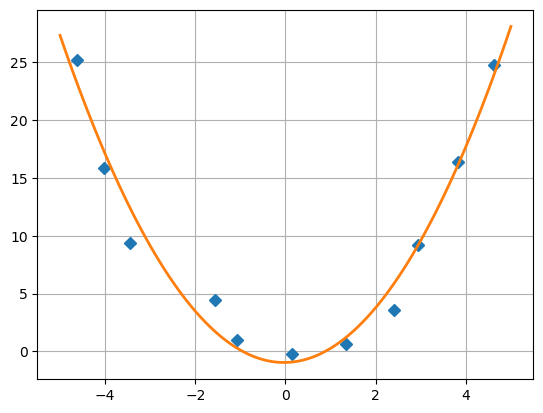

In [6]:
# Нахождение коэффициентов функции вида у = ax*2 + bx + с методом наименьших квадратов
# задаем вектор m = [x**2, x, E]
m = vstack((x**2, x, ones(11))).T
# находим коэффициенты при составляющих вектора т
s = np.linalg.lstsq(m, y, rcond = None)[0]
# на отрезке [-5,5]
x_prec = linspace(-5, 5, 101)
# рисуем точки
plt.plot(x, y, 'D')
# рисуем кривую вида у = ax*2 + bx + с, подставляя из решения коэффициенты s[0], s[1], s[2]
plt.plot(x_prec, s[0] * x_prec**2 + s[1] * x_prec+s[2], '-', lw=2)
plt.grid()
plt.savefig('парабола.png')

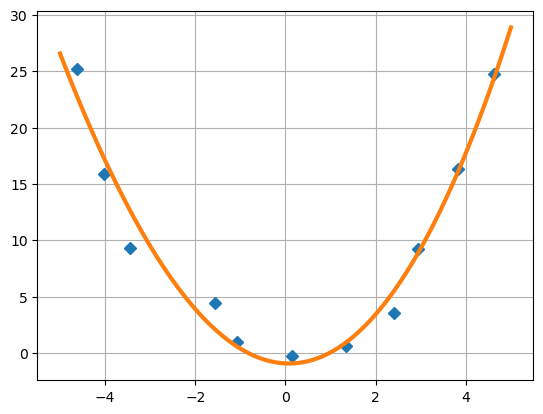

In [7]:
#Решение
# Нахождение коэффициентов функции вида у = ax*3 + bx*2 + cx + d методом наименьших квадратов
# задаем вектор m = [x**3, x, E]
m = vstack((x**3, x**2, x, ones(11))).T
# находим коэффициенты при составляющих вектора т
s = np.linalg.lstsq(m, y, rcond = None)[0]
# на отрезке [-5,5]
x_prec = linspace(-5, 5, 101)
# рисуем точки
plt.plot(x, y, 'D')
# рисуем кривую вида у = ax*3 + bx*2 + cx + d, подставляя из решения коэффициенты s[0], s[1], s[2], s[3]
plt.plot(x_prec, s[0] * x_prec**3 + s[1] * x_prec**2 + s[2]*x_prec + s[3],'-', lw = 3)
plt.grid()
plt.savefig('полином 3-й степени.png')

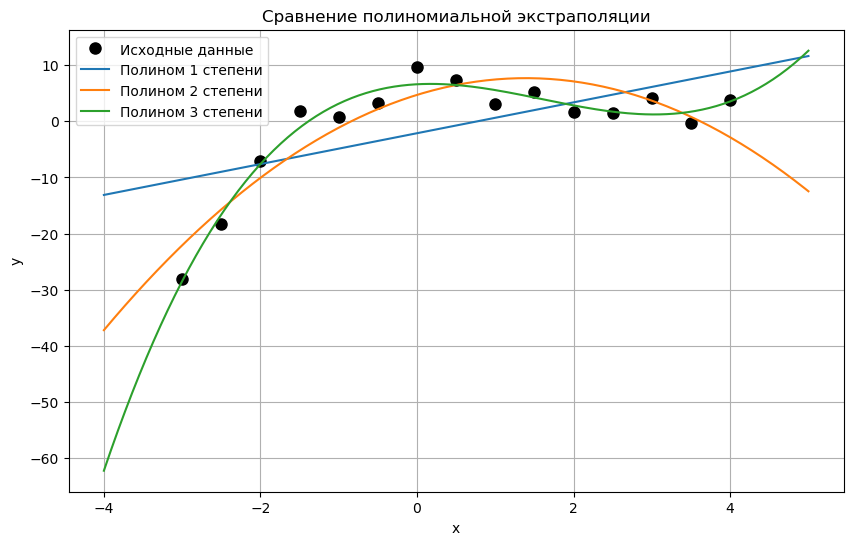

In [8]:
np.random.seed(42)
x_data = np.linspace(-3, 4, 15)
y_data = 0.5 * x_data**3 - 2 * x_data**2 + x_data + 5 + np.random.normal(0, 3, 15)

x_smooth = np.linspace(-4, 5, 200)

A1 = np.vstack([x_data, np.ones(len(x_data))]).T
coeffs1 = np.linalg.lstsq(A1, y_data, rcond=None)[0]

A2 = np.vstack([x_data**2, x_data, np.ones(len(x_data))]).T
coeffs2 = np.linalg.lstsq(A2, y_data, rcond=None)[0]

A3 = np.vstack([x_data**3, x_data**2, x_data, np.ones(len(x_data))]).T
coeffs3 = np.linalg.lstsq(A3, y_data, rcond=None)[0]

plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data, 'o', label='Исходные данные', markersize=8, color='black')
plt.plot(x_smooth, coeffs1[0] * x_smooth + coeffs1[1], label='Полином 1 степени')
plt.plot(x_smooth, coeffs2[0] * x_smooth**2 + coeffs2[1] * x_smooth + coeffs2[2], label='Полином 2 степени')
plt.plot(x_smooth, coeffs3[0] * x_smooth**3 + coeffs3[1] * x_smooth**2 + coeffs3[2] * x_smooth + coeffs3[3], label='Полином 3 степени')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Сравнение полиномиальной экстраполяции')
plt.legend(); plt.grid(); plt.show()

[0.         0.10204082 0.20408163 0.30612245 0.40816327 0.51020408
 0.6122449  0.71428571 0.81632653 0.91836735 1.02040816 1.12244898
 1.2244898  1.32653061 1.42857143 1.53061224 1.63265306 1.73469388
 1.83673469 1.93877551 2.04081633 2.14285714 2.24489796 2.34693878
 2.44897959 2.55102041 2.65306122 2.75510204 2.85714286 2.95918367
 3.06122449 3.16326531 3.26530612 3.36734694 3.46938776 3.57142857
 3.67346939 3.7755102  3.87755102 3.97959184 4.08163265 4.18367347
 4.28571429 4.3877551  4.48979592 4.59183673 4.69387755 4.79591837
 4.89795918 5.        ]
[0.97188562 0.94546397 1.00025538 0.92026777 0.86944208 0.98175253
 0.86053158 0.83450448 0.71623569 0.7147293  0.70116177 0.5919158
 0.6231705  0.53110449 0.50575115 0.45236726 0.54042158 0.41590782
 0.33594805 0.40563562 0.28242474 0.33594485 0.21237427 0.23134229
 0.29723005 0.31589217 0.28078205 0.26107481 0.24760473 0.18548311
 0.22092855 0.23200576 0.30648513 0.26976807 0.1636733  0.26747866
 0.23162652 0.2167561  0.28099135 0.301

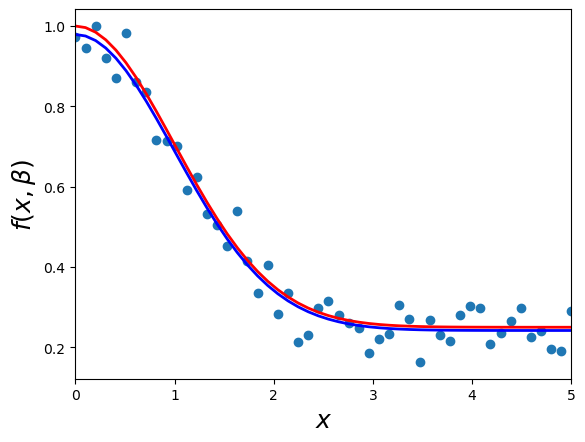

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.optimize import curve_fit

# Добавим шума в данные, сделанные по функции f(x, b) с коэффициентами b = (0.25, 0.75, 0.5)
beta = (0.25, 0.75, 0.5)

def f(x, b0, b1, b2):
    return b0 + b1 * np.exp(-b2 * x**2)

# зададим массив точек xi
xdata = np.linspace(0, 5, 50)

# создаем теоретически правильные значения точек yi (без шума)
y = f(xdata, *beta)

# зашумляем эти данные
ydata = y + 0.05 * np.random.randn(len(xdata))
print(xdata); print(ydata)

# Используем функцию для получения решения в виде коэффициентов функции f(x) для указанных xdata и ydata
beta_opt, beta_cov = sp.optimize.curve_fit(f, xdata, ydata)
print(beta_opt)

# Вычислим линейное отклонение
lin_dev = sum(beta_cov[0])
print(lin_dev)

# Вычислим квадратичное отклонение
residuals = ydata - f(xdata, *beta_opt)
fres = sum(residuals**2)
print(fres)

# Визуализация
fig, ax = plt.subplots()
ax.scatter(xdata, ydata)
ax.plot(xdata, y, 'r', lw=2)
ax.plot(xdata, f(xdata, *beta_opt), 'b', lw=2)
ax.set_xlim(0, 5)
ax.set_xlabel(r"$x$", fontsize=18)
ax.set_ylabel(r"$f(x, \beta)$", fontsize=18)
plt.show()

[0.25706212 0.74755152]
0.00012885290109071278
0.11330168910365208


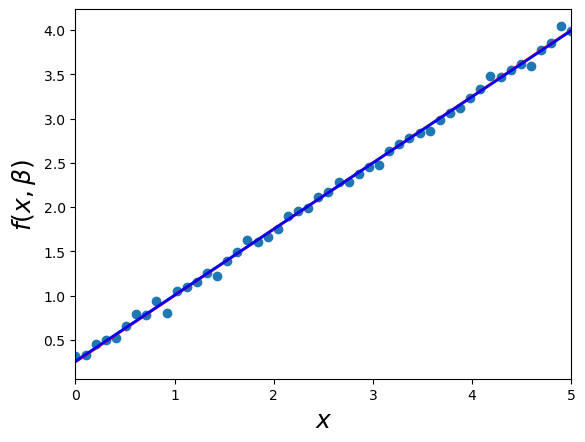

In [10]:
#решение
#1
#Добавим шума в данные, сделанные по функции f(x,b) с коэффициентами b = (0.25, 0.75)
beta = (0.25, 0.75)
def f(x, b0, b1):
    return b0 + b1 * x
# зададим массив точек xi
xdata = np.linspace(0, 5, 50)
# создаем теоретически правильные значения точек yi (без шума)
y = f(xdata, *beta)
# зашумляем эти данные
ydata = y + 0.05 * np.random.randn(len(xdata))
beta_opt, beta_cov = sp.optimize.curve_fit(f, xdata, ydata)
print(beta_opt)
#Вычислим линейное отклонение
lin_dev = sum(beta_cov[0])
print(lin_dev)

#Вычислим квадратичное отклонение
residuals = ydata - f(xdata,*beta_opt)
fres = sum(residuals**2)
print(fres)

fig, ax = plt.subplots()
ax.scatter(xdata, ydata)
ax.plot(xdata, y, 'r', lw=2)
ax.plot(xdata, f(xdata, *beta_opt), 'b', lw=2)
ax.set_xlim(0, 5)
ax.set_xlabel(r"$x$", fontsize=18)
ax.set_ylabel(r"$f(x, \beta)$", fontsize=18)
plt.show()

[0.26347516 0.73168627 0.50393185]
0.00013230141930345053
0.11032553128999206


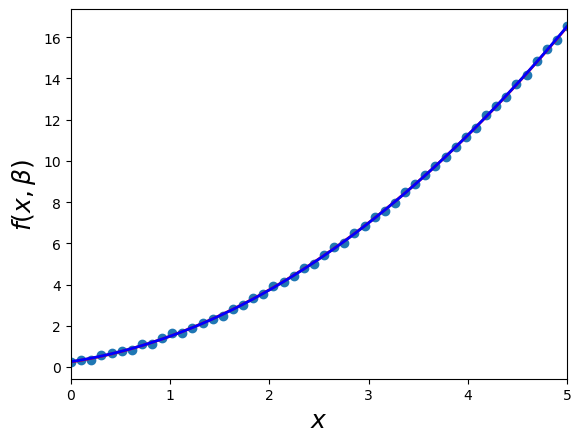

In [11]:
#решение
#2
#Добавим шума в данные, сделанные по функции f(x,b) с коэффициентами b = (0.25, 0.75, 0.5)
beta = (0.25, 0.75, 0.5)
def f(x, b0, b1, b2):
    return b0 + b1 * x + b2 * x * x
# зададим массив точек xi
xdata = np.linspace(0, 5, 50)
# создаем теоретически правильные значения точек yi (без шума)
y = f(xdata, *beta)
# зашумляем эти данные
ydata = y + 0.05 * np.random.randn(len(xdata))
beta_opt, beta_cov = sp.optimize.curve_fit(f, xdata, ydata)
print(beta_opt)
#Вычислим линейное отклонение
lin_dev = sum(beta_cov[0])
print(lin_dev)

#Вычислим квадратичное отклонение
residuals = ydata - f(xdata,*beta_opt)
fres = sum(residuals**2)
print(fres)

fig, ax = plt.subplots()
ax.scatter(xdata, ydata)
ax.plot(xdata, y, 'r', lw=2)
ax.plot(xdata, f(xdata, *beta_opt), 'b', lw=2)
ax.set_xlim(0, 5)
ax.set_xlabel(r"$x$", fontsize=18)
ax.set_ylabel(r"$f(x, \beta)$", fontsize=18)
plt.show()

[1.00401168 2.00661987]
5.390141182938366e-05
0.12464385693226825


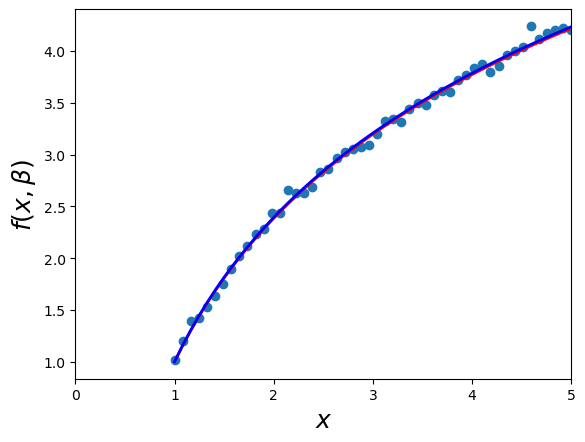

In [12]:
#решение
#3
#Добавим шума в данные, сделанные по функции f(x,b) с коэффициентами b = (1, 2)
beta = (1, 2)
def f(x, b0, b1):
    return b0 + b1 * np.log(x)
# зададим массив точек xi
xdata = np.linspace(1, 5, 50)
# создаем теоретически правильные значения точек yi (без шума)
y = f(xdata, *beta)
# зашумляем эти данные
ydata = y + 0.05 * np.random.randn(len(xdata))
beta_opt, beta_cov = sp.optimize.curve_fit(f, xdata, ydata)
print(beta_opt)
#Вычислим линейное отклонение
lin_dev = sum(beta_cov[0])
print(lin_dev)

#Вычислим квадратичное отклонение
residuals = ydata - f(xdata,*beta_opt)
fres = sum(residuals**2)
print(fres)

fig, ax = plt.subplots()
ax.scatter(xdata, ydata)
ax.plot(xdata, y, 'r', lw=2)
ax.plot(xdata, f(xdata, *beta_opt), 'b', lw=2)
ax.set_xlim(0, 5)
ax.set_xlabel(r"$x$", fontsize=18)
ax.set_ylabel(r"$f(x, \beta)$", fontsize=18)
plt.show()

[1.00239831 1.99794842]
6.35610463736463e-06
0.14983687414713504


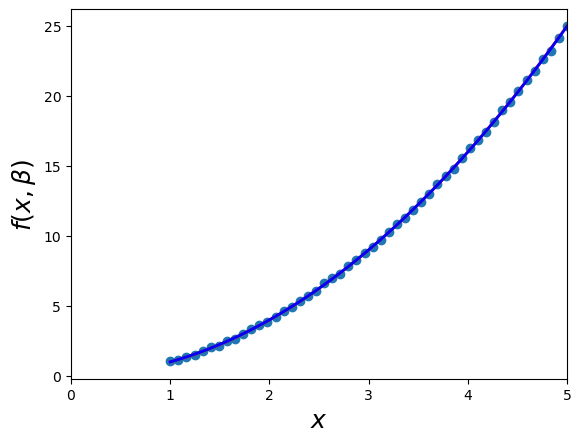

In [13]:
#решение
#4
#Добавим шума в данные, сделанные по функции f(x,b) с коэффициентами b = (1, 2)
beta = (1, 2)
def f(x, b0, b1):
    return b0 * x ** b1
# зададим массив точек xi
xdata = np.linspace(1, 5, 50)
# создаем теоретически правильные значения точек yi (без шума)
y = f(xdata, *beta)
# зашумляем эти данные
ydata = y + 0.05 * np.random.randn(len(xdata))
beta_opt, beta_cov = sp.optimize.curve_fit(f, xdata, ydata)
print(beta_opt)
#Вычислим линейное отклонение
lin_dev = sum(beta_cov[0])
print(lin_dev)

#Вычислим квадратичное отклонение
residuals = ydata - f(xdata,*beta_opt)
fres = sum(residuals**2)
print(fres)

fig, ax = plt.subplots()
ax.scatter(xdata, ydata)
ax.plot(xdata, y, 'r', lw=2)
ax.plot(xdata, f(xdata, *beta_opt), 'b', lw=2)
ax.set_xlim(0, 5)
ax.set_xlabel(r"$x$", fontsize=18)
ax.set_ylabel(r"$f(x, \beta)$", fontsize=18)
plt.show()

Найденные коэффициенты: [ 0.54365491 -0.29977815  0.18373556]
Линейное отклонение: 0.0005547398180169404
Квадратичное отклонение: 0.43937004090696535


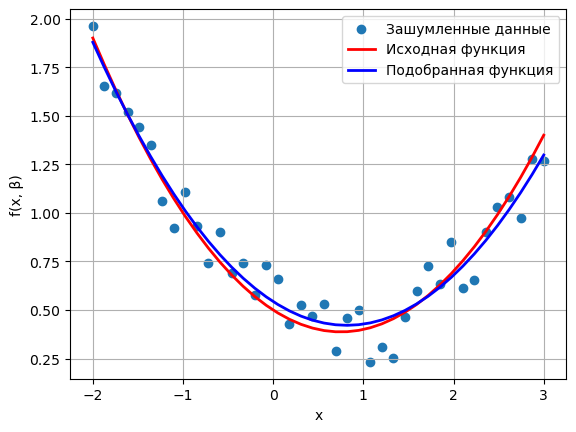


Анализ изменения данных:
Исходные коэффициенты: b0=0.5, b1=-0.3, b2=0.2
Найденные коэффициенты: b0=0.544, b1=-0.300, b2=0.184
Погрешность определения: Δb0=0.044, Δb1=0.000, Δb2=0.016


In [17]:
# Мои данные по функции f(x,b) с коэффициентами b = (0.5, -0.3, 0.2)
beta = (0.5, -0.3, 0.2)
def f(x, b0, b1, b2):
    return b0 + b1 * x + b2 * x * x

# массив точек xi
xdata = np.linspace(-2, 3, 40)
# теоретические значения (без шума)
y = f(xdata, *beta)
# зашумленные данные
ydata = y + 0.1 * np.random.randn(len(xdata))

# подбор параметров
beta_opt, beta_cov = sp.optimize.curve_fit(f, xdata, ydata)
print("Найденные коэффициенты:", beta_opt)

# линейное отклонение
lin_dev = sum(beta_cov[0])
print("Линейное отклонение:", lin_dev)
# квадратичное отклонение
residuals = ydata - f(xdata, *beta_opt)
fres = sum(residuals**2)
print("Квадратичное отклонение:", fres)

# график
fig, ax = plt.subplots()
ax.scatter(xdata, ydata, label='Зашумленные данные')
ax.plot(xdata, y, 'r', lw=2, label='Исходная функция')
ax.plot(xdata, f(xdata, *beta_opt), 'b', lw=2, label='Подобранная функция')
ax.set_xlabel("x")
ax.set_ylabel("f(x, β)")
ax.legend()
ax.grid(True)
plt.show()

# анализ динамики
print("\nАнализ изменения данных:")
print(f"Исходные коэффициенты: b0={beta[0]}, b1={beta[1]}, b2={beta[2]}")
print(f"Найденные коэффициенты: b0={beta_opt[0]:.3f}, b1={beta_opt[1]:.3f}, b2={beta_opt[2]:.3f}")
print(f"Погрешность определения: Δb0={abs(beta[0]-beta_opt[0]):.3f}, Δb1={abs(beta[1]-beta_opt[1]):.3f}, Δb2={abs(beta[2]-beta_opt[2]):.3f}")

In [1]:
# Импортируем необходимые библиотеки
# используем pandas и numpy для обработки данных,
# matplotlib для визуализации и sklearn для обучения наборов данных и импорта моделей.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import DataFrame, Series
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
# создадим набор данных для описания взаимосвязи между временем обучения студентов и успеваемостью
my_dict = {
    'Учебное время': [0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50, 2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50],
    'Оценка': [10, 22, 13, 43, 20, 22, 33, 50, 62, 48, 55, 75, 62, 73, 81, 76, 64, 82, 90, 93]
}

dataset = pd.DataFrame(my_dict)
dataset.head()

,Учебное время,Оценка
0,0.50,10
1,0.75,22
2,1.00,13
3,1.25,43
4,1.50,20


In [3]:
# Исследуем набор данных
print(dataset.shape)
dataset.describe()

(20, 2)


,Учебное время,Оценка
count,20.000000,20.000000
mean,2.787500,53.700000
std,1.507165,26.435821
min,0.500000,10.000000
25%,1.687500,30.250000
50%,2.625000,58.500000
75%,4.062500,75.250000
max,5.500000,93.000000


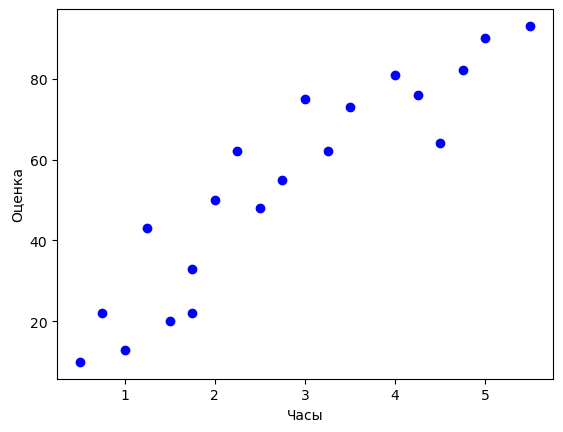

In [4]:
# Нарисуем точечную диаграмму
plt.scatter(dataset['Учебное время'], dataset['Оценка'], color = 'b', label = "данные экзамена")
plt.xlabel("Часы")
plt.ylabel("Оценка")
plt.show()

In [5]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 1].values
print(X)
print(y)

[[0.5 ]
 [0.75]
 [1.  ]
 [1.25]
 [1.5 ]
 [1.75]
 [1.75]
 [2.  ]
 [2.25]
 [2.5 ]
 [2.75]
 [3.  ]
 [3.25]
 [3.5 ]
 [4.  ]
 [4.25]
 [4.5 ]
 [4.75]
 [5.  ]
 [5.5 ]]
[10 22 13 43 20 22 33 50 62 48 55 75 62 73 81 76 64 82 90 93]


In [7]:
# Теперь, когда у нас есть атрибуты и метки, необходимо разделить их на а обучающий и тестовый наборы.
# Приведенный фрагмент разделяет 80% данных на обучающий набор, а 20% данных - на набор тестов
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
# далее можно обучить алгоритм линейной регрессии
# необходимо импортировать класс LinearRegression, создать его экземпляр и вызвать метод fit()
regressor = LinearRegression()
regressor.fit(X_train, y_train)
# приведем получившиеся коэффициенты для линии регрессии
print(regressor.intercept_)
print(regressor.coef_)

5.475400029908791
[17.02706744]


In [9]:
y_pred = regressor.predict(X_test)
# сравним фактические значения с прогнозируемыми
df = DataFrame({'Actual': y_test, 'Predicted': y_pred})
df

,Actual,Predicted
0,90,90.610737
1,22,18.245701
2,93,99.124271
3,62,43.786302


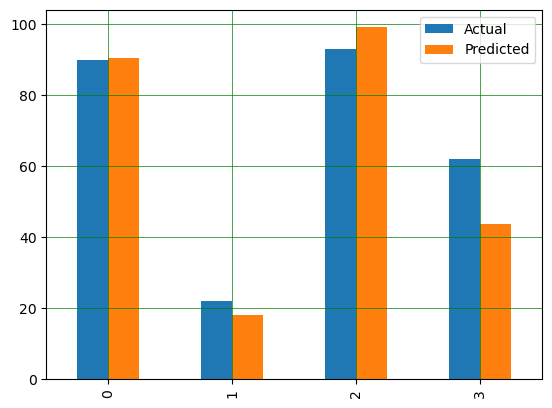

In [11]:
# визуализируем результат сравнения в виде гистограммы
df.plot(kind='bar')
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle='-', linewidth='0.5', color='black')
plt.show()

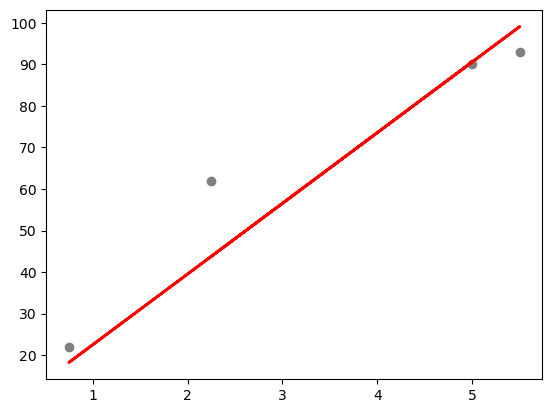

In [12]:
# построим линюю регрессии с тестовыми данными
plt.scatter(X_test, y_test, color='gray')
plt.plot(X_test, y_pred, color='red', linewidth=2)
plt.show()

In [27]:
df = pd.read_csv('https://raw.githubusercontent.com/AnnaShestova/salary-years-simple-linear-regression/master/Salary_Data.csv')
# Найдите коэффициенты линии регрессии. Постройте прогноз.
X, y = df.iloc[:, :-1].values, df.iloc[:, 1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
regressor = LinearRegression()
regressor.fit(X_train, y_train)
print(regressor.intercept_, regressor.coef_)
y_pred = regressor.predict(X_test)
pd.DataFrame({'actual': y_test, 'predicted': y_pred})

26780.099150628186 [9312.57512673]


,actual,predicted
0,37731.0,40748.961841
1,122391.0,122699.622956
2,57081.0,64961.657170
3,63218.0,63099.142145
4,116969.0,115249.562855
5,109431.0,107799.502753


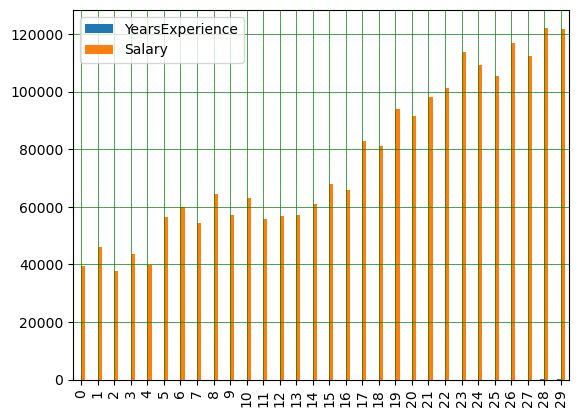

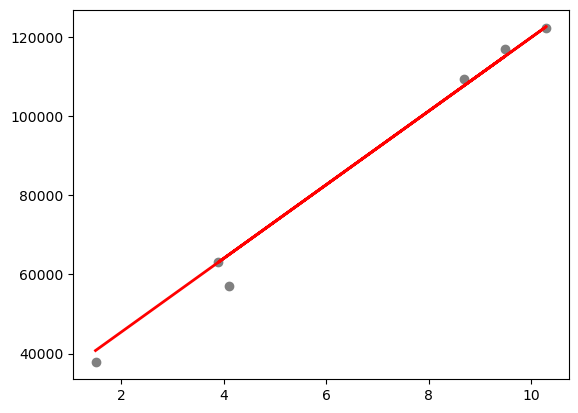

In [25]:
df.plot(kind='bar')
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle='-', linewidth='0.5', color='black')
plt.show()

plt.scatter(X_test, y_test, color='gray')
plt.plot(X_test, y_pred, color='red', linewidth=2)
plt.show()

In [2]:
import numpy as np

# целевые значения
y = [1, 2, 3, 4, 3, 4, 5, 3, 5, 5, 4, 5, 4, 5, 4, 5, 6, 0, 6, 3, 1, 3, 1]

# матрица признаков (3 признака для каждого наблюдения)
X = [
    [0, 2, 4, 1, 5, 4, 5, 9, 9, 9, 3, 7, 8, 8, 6, 6, 5, 5, 5, 6, 6, 5, 5],
    [4, 1, 2, 3, 4, 5, 6, 7, 5, 8, 7, 8, 7, 8, 7, 8, 6, 8, 9, 2, 1, 5, 6],
    [4, 1, 2, 5, 6, 7, 8, 9, 7, 8, 7, 8, 7, 4, 3, 1, 2, 3, 4, 1, 3, 9, 7]
]

# транспонируем X, чтобы строки соответствовали отдельным наблюдениям
X = np.transpose(X) 

# добавляем столбец из единиц (свободный член) к матрице признаков
X = np.c_[X, np.ones(X.shape[0])] 

# находим коэффициенты линейной регрессии методом наименьших квадратов
# lstsq возвращает несколько значений, нам нужен только первый элемент - вектор весов
linreg = np.linalg.lstsq(X, y, rcond=None)[0]

print(linreg)

[ 0.1338682   0.26840334 -0.02874936  1.5122571 ]


In [5]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seabornInstance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

y = [1,2,3,4,3,4,5,3,5,5,4,5,4,5,4,5,6,0,6,3,1,3,1]
X = [[0,2,4,1,5,4,5,9,9,9,3,7,8,8,6,6,5,5,5,6,6,5,5],
     [4,1,2,3,4,5,6,7,5,8,7,8,7,8,7,8,6,8,9,2,1,5,6],
     [4,1,2,5,6,7,8,9,7,8,7,8,7,4,3,1,2,3,4,1,3,9,7]]

# формируем DataFrame из двух списков
new_y = np.array(y)
new_y = new_y.transpose()
df1 = pd.DataFrame(new_y)
new_X = np.array(X)
new_X = new_X.transpose()
df2 = pd.DataFrame(new_X)
df1 = df1.rename(columns = {0: 'y'}, inplace = False)
df2 = df2.rename(columns = {0: 'x1', 1: 'x2', 2: 'x3'}, inplace = False)

frames = [df1, df2]
dataset = pd.concat([df1, df2], axis=1, join="inner")
dataset.head()

,y,x1,x2,x3
0,1,0,4,4
1,2,2,1,1
2,3,4,2,2
3,4,1,3,5
4,3,5,4,6


In [6]:
# изучим данные
print(dataset.shape)
dataset.describe()

(23, 4)


,y,x1,x2,x3
count,23.000000,23.000000,23.000000,23.000000
mean,3.565217,5.347826,5.521739,5.043478
std,1.674029,2.404706,2.428422,2.704849
min,0.000000,0.000000,1.000000,1.000000
25%,3.000000,4.500000,4.000000,3.000000
50%,4.000000,5.000000,6.000000,5.000000
75%,5.000000,6.500000,7.500000,7.000000
max,6.000000,9.000000,9.000000,9.000000


In [7]:
# разделим данные на метки и атрибуты
X = dataset[['x1', 'x2', 'x3']]
y = dataset['y']

# разделим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 0)

# Для обучения алгоритма мы выполняем тот же код, что и раньше, используя метод fit() класса LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Выведем коэффициенты модели
coeff_df = pd.DataFrame(regressor.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
x1,0.223219
x2,0.136709
x3,-0.063757


In [8]:
# Чтобы сделать прогнозы на тестовых данных, выполните следующий код
y_pred = regressor.predict(X_test)
df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
df

,Actual,Predicted
11,5,4.119478
10,4,3.153648
21,3,3.199155
14,4,4.078333
20,1,3.258079


In [10]:
# Последний шаг - оценить производительность алгоритма. Мы сделаем это, найдя значения для MSE
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))

Mean Squared Error: 1.3272699242343062


In [28]:
df = pd.read_csv('https://raw.githubusercontent.com/aniruddhachoudhury/Red-Wine-Quality/master/winequality-red.csv')

y = df.pop('quality')
X = df

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
regressor = LinearRegression()
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison_df.head())

print('Средняя квадратичная ошибка (MSE):', metrics.mean_squared_error(y_test, y_pred))

      Actual  Predicted
1109       6   5.782930
1032       5   5.036193
1002       7   6.596989
487        6   5.339126
979        5   5.939529
Средняя квадратичная ошибка (MSE): 0.38447119782012557


In [43]:
import numpy as np

x = np.array([4.0, 4.2, 4.4, 4.6, 4.8, 5.0])
y = np.array([4.0, 3.0, 6.0, 6.0, 4.0, 4.0])

# степень 1
p1 = np.polyfit(x, y, 1)
y_pred1 = np.polyval(p1, x)
sko1 = np.sqrt(np.mean((y - y_pred1)**2))

# степень 2
p2 = np.polyfit(x, y, 2)
y_pred2 = np.polyval(p2, x)
sko2 = np.sqrt(np.mean((y - y_pred2)**2))

print(f"Линейная: y = {p1[0]:.4f}x + {p1[1]:.4f}, СКО = {sko1:.4f}")
print(f"Квадрат: y = {p2[0]:.4f}x^2 + {p2[1]:.4f}x + {p2[2]:.4f}, СКО = {sko2:.4f}")

print(y_pred1, y_pred2)

Линейная: y = 0.4286x + 2.5714, СКО = 1.1084
Квадрат: y = -6.6964x^2 + 60.6964x + -132.2500, СКО = 0.8844
[4.28571429 4.37142857 4.45714286 4.54285714 4.62857143 4.71428571] [3.39285714 4.55       5.17142857 5.25714286 4.80714286 3.82142857]
